<a href="https://colab.research.google.com/github/gowrisankar393/vaylen-transitlk/blob/ETA-Prediction/TransitLK_ETA_Prediction_XGB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TransitLK ETA Prediction Model**

## **Setup & Dependencies**

In [1]:
!pip install openpyxl xgboost scikit-learn joblib shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import openpyxl
import json
import joblib
import warnings
import os
import glob
from datetime import datetime, timedelta
from math import radians, sin, cos, sqrt, atan2
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from google.colab import files
warnings.filterwarnings('ignore')

print('All dependencies loaded')
print(f'  XGBoost : {xgb.__version__}')
print(f'  Pandas  : {pd.__version__}')
print(f'  NumPy   : {np.__version__}')

All dependencies loaded
  XGBoost : 3.2.0
  Pandas  : 2.2.2
  NumPy   : 2.0.2


## **Upload Stops XLSX**


In [2]:
print('Upload stops xlsx file')
stops_uploaded = files.upload()

def parse_coordinates(coord_str):
    """Parse '6.8148, 79.8674' or (6.8148, 79.8674) → (lat, lng)"""
    parts = str(coord_str).replace('(','').replace(')','').split(',')
    parts = [p.strip() for p in parts if p.strip()]
    if len(parts) >= 2:
        try:
            return float(parts[0]), float(parts[1])
        except:
            pass
    return None, None

def load_stops_from_xlsx(filepath):
    wb = openpyxl.load_workbook(filepath)
    sheet_names = wb.sheetnames
    if len(sheet_names) < 2:
        raise ValueError(f'Expected 2 sheets, got {len(sheet_names)}')

    def parse_sheet(sheet):
        stops = {}
        rows = list(sheet.iter_rows(values_only=True))
        for row in rows[1:]:#skip header
            if not row[0]: continue
            name = str(row[0]).strip()
            lat, lng = parse_coordinates(row[1])
            if lat and lng and name:
                stops[name] = (lat, lng)
        return stops

    stops_out = parse_sheet(wb[sheet_names[0]])
    stops_ret = parse_sheet(wb[sheet_names[1]])
    return stops_out, stops_ret, sheet_names[0], sheet_names[1]

stops_filename = list(stops_uploaded.keys())[0]
STOPS_OUTBOUND, STOPS_RETURN, LABEL_OUT, LABEL_RET = load_stops_from_xlsx(stops_filename)
ROUTE_ID = None #will be set in the export cell

print(f'\nStops file: {stops_filename}')
print(f'Outbound  ({LABEL_OUT}): {len(STOPS_OUTBOUND)} stops')
print(f'Return    ({LABEL_RET}): {len(STOPS_RETURN)} stops')

#convert to ordered lists for index-based access
STOPS_OUT_LIST = [{'name': k, 'lat': v[0], 'lng': v[1], 'idx': i}
                  for i, (k, v) in enumerate(STOPS_OUTBOUND.items())]
STOPS_RET_LIST = [{'name': k, 'lat': v[0], 'lng': v[1], 'idx': i}
                  for i, (k, v) in enumerate(STOPS_RETURN.items())]

print(f'\nOutbound stops:')
for s in STOPS_OUT_LIST:
    print(f'  {s["idx"]:2d}. {s["name"]}')
print(f'\nReturn stops:')
for s in STOPS_RET_LIST:
    print(f'  {s["idx"]:2d}. {s["name"]}')

Upload stops xlsx file


Saving 256-341-1_stops.xlsx to 256-341-1_stops.xlsx

Stops file: 256-341-1_stops.xlsx
Outbound  (R2M): 26 stops
Return    (M2R): 26 stops

Outbound stops:
   0. Ratmalana Railway Station
   1. Belekkade Junction
   2. Ratmalana Airport
   3. Golumadama Junction
   4. Stein Studio
   5. Ratmalana Hindu College
   6. Vijaya Mawathe
   7. 8th Cross Lane
   8. Sethsiri Road
   9. Samanala Road
  10. Jayanthi Place
  11. Peiris Mawatha
  12. Kahatagahawatte Road
  13. Metishuddagara Mawathe (Wanguwa)
  14. Gangarama Junction
  15. RMV
  16. Neelammahara Junction
  17. 1st Lane
  18. Temple Road
  19. Henagedara Road
  20. Thappawaththa Road
  21. Jaya Mawatha
  22. Sadu Mawatha
  23. 1st lane (2)
  24. Neelammahara Junction (M)
  25. Maharagama

Return stops:
   0. Maharagama
   1. Neelammahara Junction
   2. 1st lane (2)
   3. Sadu Mawatha
   4. Jaya Mawatha
   5. Thappawaththa Road
   6. Henagedara Road
   7. Temple Road
   8. 1st Lane
   9. Katuwawala
  10. RMV
  11. Gangarama Junction
 

## **Load Trip CSVs from Google Drive**


In [3]:
from google.colab import drive
drive.mount('/content/drive')

CSV_FOLDER = '/content/drive/MyDrive/Colab Notebooks/TransitLK CSV Logs'

if not os.path.exists(CSV_FOLDER):
    raise FileNotFoundError(f'Folder not found: {CSV_FOLDER}')

csv_files = sorted(glob.glob(os.path.join(CSV_FOLDER, '*.csv')))
if not csv_files:
    raise FileNotFoundError(f'No CSV files found in: {CSV_FOLDER}')

print(f'Found {len(csv_files)} trip CSV(s):')
for f in csv_files:
    print(f'  {os.path.basename(f)}  ({os.path.getsize(f)/1024:.1f} KB)')

Mounted at /content/drive
Found 69 trip CSV(s):
  trip_1771927745437_153918.csv  (588.8 KB)
  trip_1771931001184_164155.csv  (588.8 KB)
  trip_1771931515715_165351.csv  (588.8 KB)
  trip_1772187473699_154811.csv  (588.8 KB)
  trip_1772187551617_155042.csv  (103.4 KB)
  trip_1772187647301_155231.csv  (588.8 KB)
  trip_1772199057832_190132.csv  (588.8 KB)
  trip_1772534779524_163840.csv  (193.4 KB)
  trip_1772536678044_173714.csv  (416.7 KB)
  trip_1772541249718_184658.csv  (362.4 KB)
  trip_1772585062761_064610.csv  (271.6 KB)
  trip_1772587735007_080545.csv  (550.6 KB)
  trip_1772591794591_085334.csv  (405.1 KB)
  trip_1772594646374_100419.csv  (582.0 KB)
  trip_1772598889508_104754.csv  (369.5 KB)
  trip_1772601764976_124358.csv  (926.1 KB)
  trip_1772611137908_140439.csv  (297.1 KB)
  trip_1772613341599_160128.csv  (975.3 KB)
  trip_1772620534987_164056.csv  (302.5 KB)
  trip_1772622897122_180453.csv  (668.1 KB)
  trip_1772627703383_184636.csv  (351.7 KB)
  trip_1772757979806_070051.

## **Configuration**

In [4]:
DETECTION_RADIUS  = 25 #meters — GPS point counts as 'at stop' within this radius
MIN_STOP_DWELL    = 3    # seconds — minimum time at a stop to count as a real stop visit
GPS_INTERVAL_SEC  = 5    # seconds between GPS points (adjust to match your driver app)
MAX_ETA_MINUTES   = 120  # cap for outlier removal

print('Configuration:')
print(f'  Detection radius : {DETECTION_RADIUS}m')
print(f'  Min stop dwell   : {MIN_STOP_DWELL}s')
print(f'  GPS interval     : {GPS_INTERVAL_SEC}s')
print(f'  Max ETA cap      : {MAX_ETA_MINUTES} mins')
print(f'  Outbound stops   : {len(STOPS_OUTBOUND)}')
print(f'  Return stops     : {len(STOPS_RETURN)}')

Configuration:
  Detection radius : 25m
  Min stop dwell   : 3s
  GPS interval     : 5s
  Max ETA cap      : 120 mins
  Outbound stops   : 26
  Return stops     : 26


## **Helper Functions**

In [5]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    φ1, φ2 = radians(lat1), radians(lat2)
    dφ = radians(lat2 - lat1)
    dλ = radians(lon2 - lon1)
    a = sin(dφ/2)**2 + cos(φ1)*cos(φ2)*sin(dλ/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

def detect_direction(df):
    """Detect trip direction from GPS start point vs first stop of each direction."""
    start_lat = df['lat'].iloc[:min(10, len(df))].mean()
    start_lng = df['lng'].iloc[:min(10, len(df))].mean()
    out_first = STOPS_OUT_LIST[0]
    ret_first = STOPS_RET_LIST[0]
    d_out = haversine(start_lat, start_lng, out_first['lat'], out_first['lng'])
    d_ret = haversine(start_lat, start_lng, ret_first['lat'], ret_first['lng'])
    if d_out <= d_ret:
        return 'OUTBOUND', STOPS_OUT_LIST, LABEL_OUT
    else:
        return 'RETURN', STOPS_RET_LIST, LABEL_RET

def find_nearest_stop(lat, lng, stops_list):
    """Return (stop, distance) of nearest stop within DETECTION_RADIUS."""
    best, best_dist = None, float('inf')
    for stop in stops_list:
        d = haversine(lat, lng, stop['lat'], stop['lng'])
        if d < best_dist and d <= DETECTION_RADIUS:
            best, best_dist = stop, d
    return best, best_dist if best else None

def parse_timestamp(df, filename):
    """
    Parse timestamps from CSV. Falls back to inferring from filename or
    generating synthetic timestamps using GPS_INTERVAL_SEC.
    """
    if 'timestamp' in df.columns:
        ts = pd.to_numeric(df['timestamp'], errors='coerce')
        if ts.notna().sum() > len(df) * 0.5:
            # Unix milliseconds
            if ts.median() > 1e10:
                df['datetime'] = pd.to_datetime(ts, unit='ms', errors='coerce')
            else:
                df['datetime'] = pd.to_datetime(ts, unit='s', errors='coerce')
            if df['datetime'].notna().sum() > len(df) * 0.5:
                return df
        # Try string datetime
        df['datetime'] = pd.to_datetime(df['timestamp'], errors='coerce')
        if df['datetime'].notna().sum() > len(df) * 0.5:
            return df

    # Fallback: try to extract date from filename e.g. 'trip_20240315_0830.csv'
    import re
    date_match = re.search(r'(\d{8})', os.path.basename(filename))
    if date_match:
        base_date = pd.to_datetime(date_match.group(1), format='%Y%m%d')
    else:
        base_date = pd.Timestamp('2024-01-01')  # default
        print(f'  ⚠ No timestamp found, using synthetic dates from {base_date.date()}')

    df['datetime'] = [base_date + timedelta(seconds=i*GPS_INTERVAL_SEC)
                      for i in range(len(df))]
    return df

print('Helper functions ready')

Helper functions ready


## **Load & Label Trip Data**


In [6]:
print('Loading and labelling trip data...\n')

all_segments = []  # each row = one GPS point with labels
trip_summaries = []

for filepath in csv_files:
    filename = os.path.basename(filepath)
    print(f'Processing: {filename}')

    df = pd.read_csv(filepath)

    required = ['lat', 'lng', 'speed_mps']
    missing = [c for c in required if c not in df.columns]
    if missing:
        print(f'  ⚠ Missing columns {missing} — skipping')
        continue

    df = parse_timestamp(df, filepath)
    direction, stops_list, dir_label = detect_direction(df)
    n_stops = len(stops_list)
    print(f'  Direction : {direction} ({dir_label}), {n_stops} stops, {len(df)} GPS points')

    # ── Label each GPS point ──────────────────────────────────────────
    df['at_stop_name']   = None
    df['at_stop_idx']    = -1
    df['direction']      = direction
    df['trip_file']      = filename

    for idx, row in df.iterrows():
        stop, dist = find_nearest_stop(row['lat'], row['lng'], stops_list)
        if stop:
            df.at[idx, 'at_stop_name'] = stop['name']
            df.at[idx, 'at_stop_idx']  = stop['idx']

    # ── Extract stop arrival times ────────────────────────────────────
    # For each stop, find the first GPS point that landed at it
    stop_arrivals = {}  # stop_idx → datetime
    at_stop_df = df[df['at_stop_idx'] >= 0].copy()

    for stop_idx in sorted(at_stop_df['at_stop_idx'].unique()):
        stop_points = at_stop_df[at_stop_df['at_stop_idx'] == stop_idx]
        if len(stop_points) >= max(1, MIN_STOP_DWELL // GPS_INTERVAL_SEC):
            stop_arrivals[int(stop_idx)] = stop_points['datetime'].iloc[0]

    detected_stops = sorted(stop_arrivals.keys())
    print(f'  Stop arrivals detected: {len(detected_stops)} / {n_stops}')

    if len(detected_stops) < 3:
        print(f'  ⚠ Too few stops detected — skipping trip')
        continue

    # ── Build training segments ───────────────────────────────────────
    # For each GPS point between stop A and stop B:
    # features = position, speed, time, temporal context
    # target   = minutes remaining to each upcoming stop

    for i, row_idx in enumerate(df.index):
        row = df.loc[row_idx]
        current_stop_idx = int(row['at_stop_idx'])
        current_time = row['datetime']

        if pd.isna(current_time):
            continue

        # Find last departed stop (stop we just left)
        last_stop_idx = -1
        for s_idx in reversed(detected_stops):
            if stop_arrivals[s_idx] <= current_time:
                last_stop_idx = s_idx
                break

        if last_stop_idx < 0:
            continue

        # Time elapsed since last stop
        elapsed_sec = (current_time - stop_arrivals[last_stop_idx]).total_seconds()
        if elapsed_sec < 0 or elapsed_sec > MAX_ETA_MINUTES * 60:
            continue

        # Temporal features
        hour         = current_time.hour
        minute       = current_time.minute
        day_of_week  = current_time.dayofweek   # 0=Mon, 6=Sun
        is_weekend   = int(day_of_week >= 5)
        is_rush_hour = int((7 <= hour <= 9) or (16 <= hour <= 19))
        time_of_day_min = hour * 60 + minute    # minutes since midnight

        # Cyclical encoding of hour and day (so 23:00 and 00:00 are close)
        hour_sin  = np.sin(2 * np.pi * hour / 24)
        hour_cos  = np.cos(2 * np.pi * hour / 24)
        dow_sin   = np.sin(2 * np.pi * day_of_week / 7)
        dow_cos   = np.cos(2 * np.pi * day_of_week / 7)

        # Speed features
        speed_kmh = row['speed_mps'] * 3.6
        is_slow   = int(row['speed_mps'] < 2.0)
        is_stopped = int(row['speed_mps'] < 0.5)

        # Sensor features (if available)
        accel_mag = 0.0
        gyro_mag  = 0.0
        if all(c in df.columns for c in ['ax','ay','az']):
            accel_mag = np.sqrt(row['ax']**2 + row['ay']**2 + row['az']**2)
        if all(c in df.columns for c in ['gx','gy','gz']):
            gyro_mag = np.sqrt(row['gx']**2 + row['gy']**2 + row['gz']**2)

        # GPS accuracy
        accuracy = row.get('accuracy', 10.0)

        # For each upcoming stop, compute ETA (target)
        for target_stop_idx in detected_stops:
            if target_stop_idx <= last_stop_idx:
                continue  # already passed

            eta_sec = (stop_arrivals[target_stop_idx] - current_time).total_seconds()
            if eta_sec <= 0 or eta_sec > MAX_ETA_MINUTES * 60:
                continue

            eta_min = eta_sec / 60.0

            # Distance from current position to target stop
            target_stop = stops_list[target_stop_idx]
            dist_to_target = haversine(row['lat'], row['lng'],
                                       target_stop['lat'], target_stop['lng'])

            # Number of stops remaining to target
            stops_remaining = target_stop_idx - last_stop_idx

            all_segments.append({
                # Identifiers
                'trip_file'        : filename,
                'direction'        : direction,
                'target_stop_idx'  : target_stop_idx,
                'target_stop_name' : target_stop['name'],
                'last_stop_idx'    : last_stop_idx,

                # Spatial features
                'lat'              : row['lat'],
                'lng'              : row['lng'],
                'dist_to_target_m' : dist_to_target,
                'stops_remaining'  : stops_remaining,
                'last_stop_idx'    : last_stop_idx,
                'progress_pct'     : last_stop_idx / max(n_stops - 1, 1),

                # Speed features
                'speed_mps'        : row['speed_mps'],
                'speed_kmh'        : speed_kmh,
                'is_slow'          : is_slow,
                'is_stopped'       : is_stopped,

                # Temporal features
                'hour'             : hour,
                'minute'           : minute,
                'day_of_week'      : day_of_week,
                'is_weekend'       : is_weekend,
                'is_rush_hour'     : is_rush_hour,
                'time_of_day_min'  : time_of_day_min,
                'hour_sin'         : hour_sin,
                'hour_cos'         : hour_cos,
                'dow_sin'          : dow_sin,
                'dow_cos'          : dow_cos,
                'elapsed_sec'      : elapsed_sec,

                # Sensor features
                'accel_magnitude'  : accel_mag,
                'gyro_magnitude'   : gyro_mag,
                'accuracy'         : accuracy,

                # Target
                'eta_minutes'      : eta_min,
            })

    trip_summaries.append({
        'file'      : filename,
        'direction' : direction,
        'n_points'  : len(df),
        'n_stops'   : len(detected_stops),
        'n_segments': len([s for s in all_segments if s['trip_file'] == filename]),
    })

data_df = pd.DataFrame(all_segments)
print(f'\nTotal training samples : {len(data_df)}')
print(f'Trips processed        : {len(trip_summaries)}')
print(f'Directions             : {data_df["direction"].value_counts().to_dict()}')
print(f'ETA range              : {data_df["eta_minutes"].min():.1f} – {data_df["eta_minutes"].max():.1f} mins')

Loading and labelling trip data...

Processing: trip_1771927745437_153918.csv
  Direction : OUTBOUND (R2M), 26 stops, 2840 GPS points
  Stop arrivals detected: 25 / 26
Processing: trip_1771931001184_164155.csv
  Direction : OUTBOUND (R2M), 26 stops, 2840 GPS points
  Stop arrivals detected: 25 / 26
Processing: trip_1771931515715_165351.csv
  Direction : OUTBOUND (R2M), 26 stops, 2840 GPS points
  Stop arrivals detected: 25 / 26
Processing: trip_1772187473699_154811.csv
  Direction : OUTBOUND (R2M), 26 stops, 2840 GPS points
  Stop arrivals detected: 25 / 26
Processing: trip_1772187551617_155042.csv
  Direction : OUTBOUND (R2M), 26 stops, 489 GPS points
  Stop arrivals detected: 0 / 26
  ⚠ Too few stops detected — skipping trip
Processing: trip_1772187647301_155231.csv
  Direction : OUTBOUND (R2M), 26 stops, 2840 GPS points
  Stop arrivals detected: 25 / 26
Processing: trip_1772199057832_190132.csv
  Direction : OUTBOUND (R2M), 26 stops, 2840 GPS points
  Stop arrivals detected: 25 / 26

## **Exploratory Data Analysis**

ETA Distribution Analysis



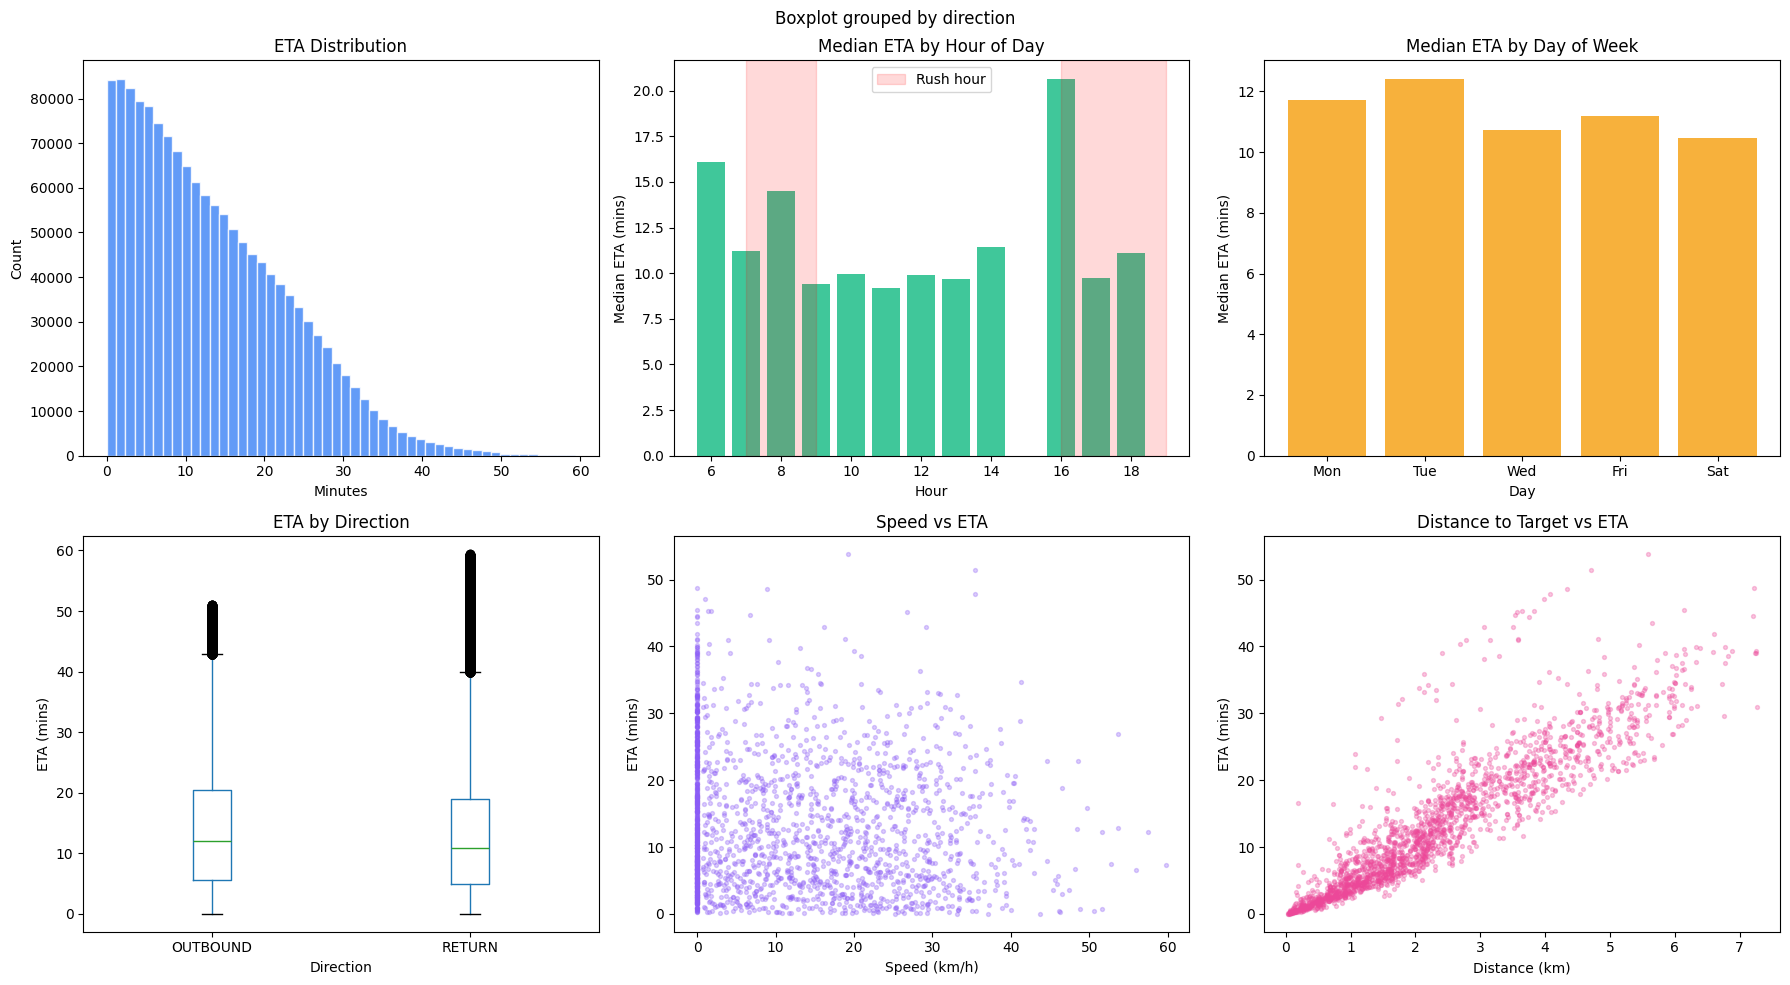


ETA Stats:
count    1456872.00
mean          13.38
std            9.87
min            0.00
25%            5.25
50%           11.47
75%           19.85
max           59.37
Name: eta_minutes, dtype: float64

Samples per direction:
direction
OUTBOUND    875661
RETURN      581211
Name: count, dtype: int64

Samples per target stop (top 10):
target_stop_name
Sadu Mawatha                 63597
1st lane (2)                 63512
Jaya Mawatha                 63470
Thappawaththa Road           63329
Maharagama                   63240
Henagedara Road              63142
1st Lane                     62712
Temple Road                  62688
Neelammahara Junction (M)    60249
Sethsiri Road                60228
Name: count, dtype: int64


In [7]:
print('ETA Distribution Analysis\n')
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('TransitLK ETA Training Data Analysis', fontsize=15, fontweight='bold')

# ETA distribution
axes[0,0].hist(data_df['eta_minutes'], bins=50, color='#3b82f6', alpha=0.8, edgecolor='white')
axes[0,0].set_title('ETA Distribution')
axes[0,0].set_xlabel('Minutes')
axes[0,0].set_ylabel('Count')

# ETA by hour of day
eta_by_hour = data_df.groupby('hour')['eta_minutes'].median()
axes[0,1].bar(eta_by_hour.index, eta_by_hour.values, color='#10b981', alpha=0.8)
axes[0,1].set_title('Median ETA by Hour of Day')
axes[0,1].set_xlabel('Hour')
axes[0,1].set_ylabel('Median ETA (mins)')
axes[0,1].axvspan(7, 9, alpha=0.15, color='red', label='Rush hour')
axes[0,1].axvspan(16, 19, alpha=0.15, color='red')
axes[0,1].legend()

# ETA by day of week
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
eta_by_dow = data_df.groupby('day_of_week')['eta_minutes'].median()
axes[0,2].bar([days[i] for i in eta_by_dow.index], eta_by_dow.values, color='#f59e0b', alpha=0.8)
axes[0,2].set_title('Median ETA by Day of Week')
axes[0,2].set_xlabel('Day')
axes[0,2].set_ylabel('Median ETA (mins)')

# ETA by direction
data_df.boxplot(column='eta_minutes', by='direction', ax=axes[1,0], grid=False)
axes[1,0].set_title('ETA by Direction')
axes[1,0].set_xlabel('Direction')
axes[1,0].set_ylabel('ETA (mins)')

# Speed vs ETA
sample = data_df.sample(min(2000, len(data_df)))
axes[1,1].scatter(sample['speed_kmh'], sample['eta_minutes'],
                  alpha=0.3, s=8, c='#8b5cf6')
axes[1,1].set_title('Speed vs ETA')
axes[1,1].set_xlabel('Speed (km/h)')
axes[1,1].set_ylabel('ETA (mins)')

# Distance to target vs ETA
axes[1,2].scatter(sample['dist_to_target_m']/1000, sample['eta_minutes'],
                  alpha=0.3, s=8, c='#ec4899')
axes[1,2].set_title('Distance to Target vs ETA')
axes[1,2].set_xlabel('Distance (km)')
axes[1,2].set_ylabel('ETA (mins)')

plt.tight_layout()
plt.show()

print('\nETA Stats:')
print(data_df['eta_minutes'].describe().round(2))
print(f'\nSamples per direction:')
print(data_df['direction'].value_counts())
print(f'\nSamples per target stop (top 10):')
print(data_df['target_stop_name'].value_counts().head(10))

## **Feature Engineering & Preprocessing**

In [8]:
print('Feature engineering...')

df_model = data_df.copy()

# Encode direction as binary
df_model['is_outbound'] = (df_model['direction'] == 'OUTBOUND').astype(int)

# Speed rolling avg proxy (approximated from current speed + is_slow/is_stopped)
df_model['traffic_score'] = df_model['is_rush_hour'] * 2 + df_model['is_slow'] + df_model['is_stopped']

# Interaction: rush hour × stops remaining
df_model['rush_x_stops'] = df_model['is_rush_hour'] * df_model['stops_remaining']

# Interaction: distance × rush hour
df_model['dist_x_rush'] = df_model['dist_to_target_m'] * (1 + df_model['is_rush_hour'] * 0.3)

# Remove outliers (> 3 std from mean per direction)
before = len(df_model)
for direction in df_model['direction'].unique():
    mask = df_model['direction'] == direction
    mean = df_model.loc[mask, 'eta_minutes'].mean()
    std  = df_model.loc[mask, 'eta_minutes'].std()
    df_model = df_model[~(mask & (np.abs(df_model['eta_minutes'] - mean) > 3 * std))]
print(f'Outlier removal: {before} → {len(df_model)} rows ({before-len(df_model)} removed)')

FEATURES = [
    # Spatial
    'lat', 'lng',
    'dist_to_target_m',
    'stops_remaining',
    'last_stop_idx',
    'target_stop_idx',
    'progress_pct',
    'is_outbound',

    # Speed / motion
    'speed_mps', 'speed_kmh',
    'is_slow', 'is_stopped',
    'accel_magnitude', 'gyro_magnitude',
    'accuracy',

    # Temporal
    'hour', 'minute',
    'day_of_week',
    'is_weekend', 'is_rush_hour',
    'time_of_day_min',
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'elapsed_sec',

    # Interaction
    'traffic_score',
    'rush_x_stops',
    'dist_x_rush',
]

X = df_model[FEATURES].copy()
y = df_model['eta_minutes'].copy()

# Fill any remaining NaNs
X = X.fillna(X.median())

print(f'\nFeature matrix : {X.shape}')
print(f'Target range   : {y.min():.2f} – {y.max():.2f} mins')
print(f'Features ({len(FEATURES)}):')
for i, f in enumerate(FEATURES, 1):
    print(f'  {i:2d}. {f}')

Feature engineering...
Outlier removal: 1456872 → 1447110 rows (9762 removed)

Feature matrix : (1447110, 29)
Target range   : 0.00 – 43.74 mins
Features (29):
   1. lat
   2. lng
   3. dist_to_target_m
   4. stops_remaining
   5. last_stop_idx
   6. target_stop_idx
   7. progress_pct
   8. is_outbound
   9. speed_mps
  10. speed_kmh
  11. is_slow
  12. is_stopped
  13. accel_magnitude
  14. gyro_magnitude
  15. accuracy
  16. hour
  17. minute
  18. day_of_week
  19. is_weekend
  20. is_rush_hour
  21. time_of_day_min
  22. hour_sin
  23. hour_cos
  24. dow_sin
  25. dow_cos
  26. elapsed_sec
  27. traffic_score
  28. rush_x_stops
  29. dist_x_rush


## **Train / Test Split**

In [9]:
# Split by trip file to prevent data leakage (same trip shouldn't be in train and test)
trip_files = df_model['trip_file'].unique()
print(f'Total trips: {len(trip_files)}')

if len(trip_files) >= 4:
    # Split trips into train/test groups
    from sklearn.model_selection import GroupShuffleSplit
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=df_model['trip_file']))
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    print(f'Split by trip file (no leakage)')
else:
    # Not enough trips for group split — use random split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f'⚠ Few trips — using random split (collect more trips for better generalisation)')

print(f'\nTrain samples : {len(X_train)}')
print(f'Test samples  : {len(X_test)}')
print(f'Train ETA mean: {y_train.mean():.2f} mins')
print(f'Test ETA mean : {y_test.mean():.2f} mins')

Total trips: 53
Split by trip file (no leakage)

Train samples : 1111748
Test samples  : 335362
Train ETA mean: 12.92 mins
Test ETA mean : 13.91 mins


## **Train XGBoost ETA Model**

In [10]:
print('Training XGBoost ETA model...\n')

model = xgb.XGBRegressor(
    n_estimators     = 500,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 3,
    gamma            = 0.1,
    reg_alpha        = 0.1,   # L1 regularisation
    reg_lambda       = 1.0,   # L2 regularisation
    random_state     = 42,
    eval_metric      = 'mae',
    early_stopping_rounds = 30,
    n_jobs           = -1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50
)

print(f'\nBest iteration: {model.best_iteration}')
print('Training complete!')

Training XGBoost ETA model...

[0]	validation_0-mae:7.39753	validation_1-mae:7.86049
[50]	validation_0-mae:1.45624	validation_1-mae:1.71110
[100]	validation_0-mae:0.90090	validation_1-mae:1.36229
[150]	validation_0-mae:0.70883	validation_1-mae:1.26645
[200]	validation_0-mae:0.61567	validation_1-mae:1.23578
[250]	validation_0-mae:0.54958	validation_1-mae:1.21360
[300]	validation_0-mae:0.50371	validation_1-mae:1.20491
[350]	validation_0-mae:0.46904	validation_1-mae:1.19431
[400]	validation_0-mae:0.43968	validation_1-mae:1.18679
[450]	validation_0-mae:0.41597	validation_1-mae:1.18106
[499]	validation_0-mae:0.39481	validation_1-mae:1.17466

Best iteration: 499
Training complete!


## **Model Evaluation**

Model Evaluation

MAE  (train) : 0.39 mins
MAE  (test)  : 1.17 mins  ← main metric
RMSE (test)  : 1.85 mins
R²   (test)  : 0.9661

Within ±2 mins : 82.6%
Within ±5 mins : 96.3%
Within ±10 mins: 100.0%


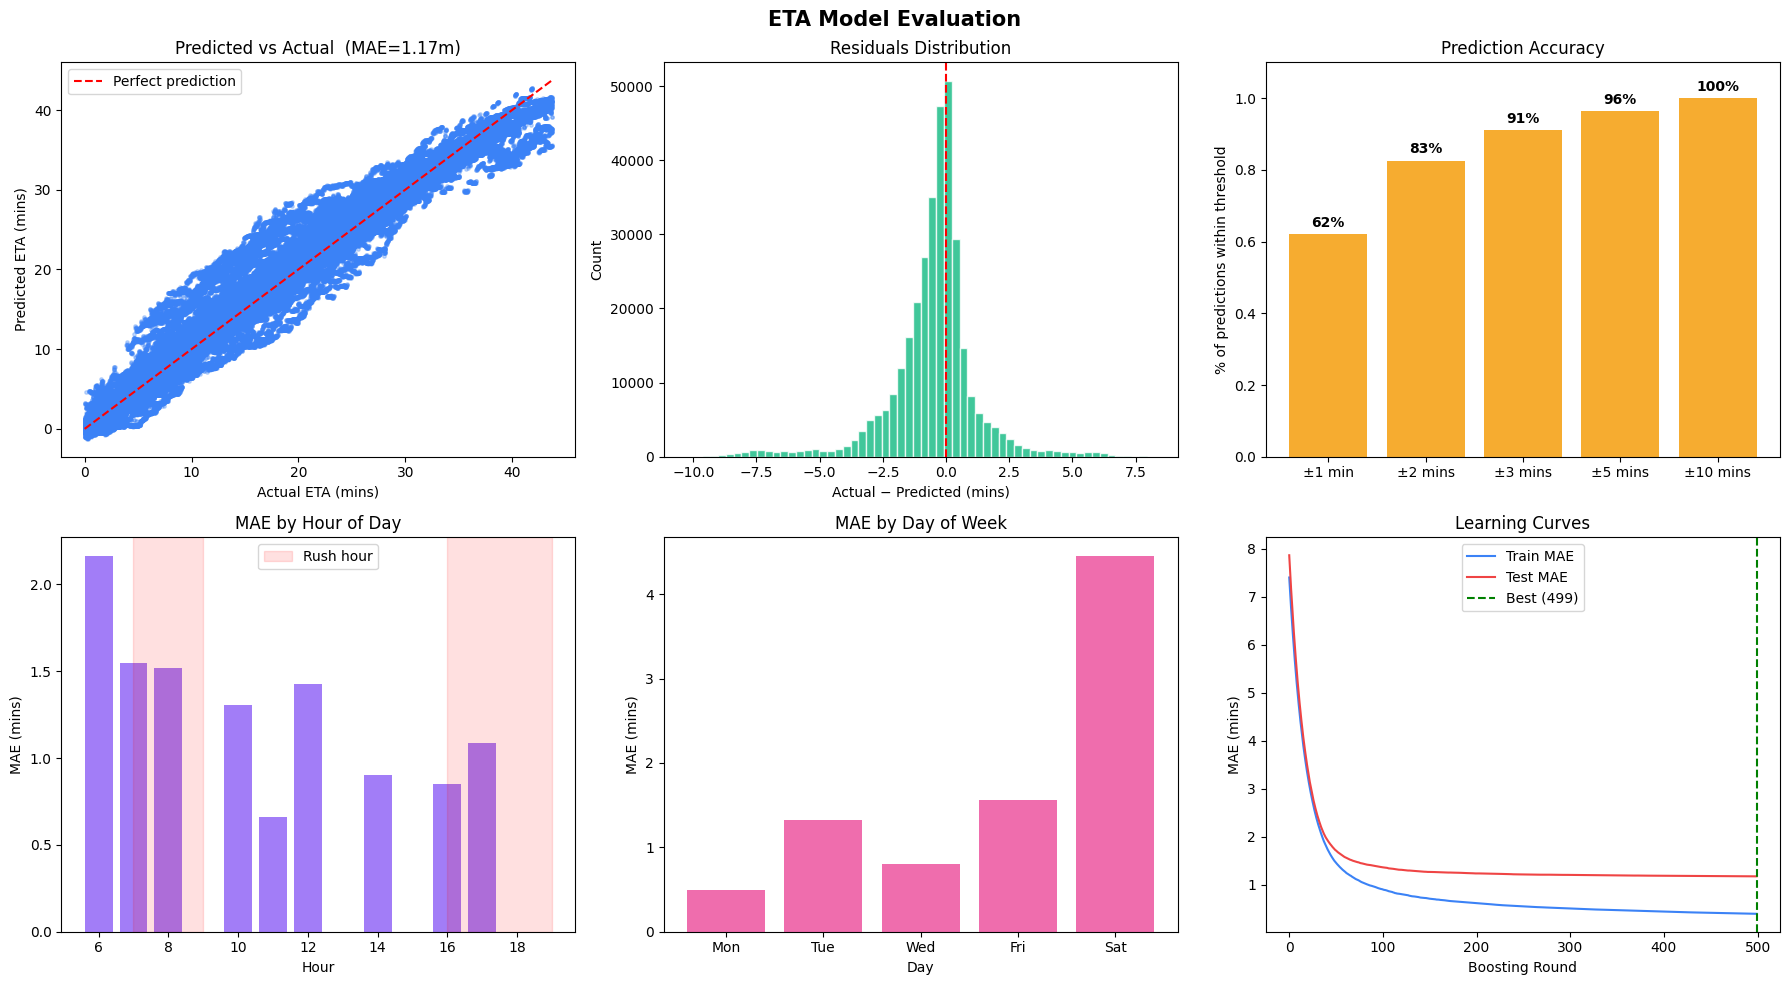

In [11]:
print('Model Evaluation\n')

y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

# Core metrics
mae_train  = mean_absolute_error(y_train, y_pred_train)
mae_test   = mean_absolute_error(y_test, y_pred_test)
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test    = r2_score(y_test, y_pred_test)

# Within-N-minutes accuracy
within_2  = (np.abs(y_test - y_pred_test) <= 2).mean()
within_5  = (np.abs(y_test - y_pred_test) <= 5).mean()
within_10 = (np.abs(y_test - y_pred_test) <= 10).mean()

print(f'MAE  (train) : {mae_train:.2f} mins')
print(f'MAE  (test)  : {mae_test:.2f} mins  ← main metric')
print(f'RMSE (test)  : {rmse_test:.2f} mins')
print(f'R²   (test)  : {r2_test:.4f}')
print(f'\nWithin ±2 mins : {within_2:.1%}')
print(f'Within ±5 mins : {within_5:.1%}')
print(f'Within ±10 mins: {within_10:.1%}')

# ── Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('ETA Model Evaluation', fontsize=15, fontweight='bold')

# Predicted vs Actual
axes[0,0].scatter(y_test, y_pred_test, alpha=0.3, s=6, c='#3b82f6')
lims = [0, max(y_test.max(), y_pred_test.max())]
axes[0,0].plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
axes[0,0].set_xlabel('Actual ETA (mins)')
axes[0,0].set_ylabel('Predicted ETA (mins)')
axes[0,0].set_title(f'Predicted vs Actual  (MAE={mae_test:.2f}m)')
axes[0,0].legend()

# Residuals distribution
residuals = y_test - y_pred_test
axes[0,1].hist(residuals, bins=60, color='#10b981', alpha=0.8, edgecolor='white')
axes[0,1].axvline(0, color='red', lw=1.5, linestyle='--')
axes[0,1].set_title('Residuals Distribution')
axes[0,1].set_xlabel('Actual − Predicted (mins)')
axes[0,1].set_ylabel('Count')

# Within-N accuracy bars
acc_labels = ['±1 min','±2 mins','±3 mins','±5 mins','±10 mins']
acc_values = [(np.abs(residuals) <= n).mean() for n in [1,2,3,5,10]]
axes[0,2].bar(acc_labels, acc_values, color='#f59e0b', alpha=0.85)
axes[0,2].set_title('Prediction Accuracy')
axes[0,2].set_ylabel('% of predictions within threshold')
axes[0,2].set_ylim(0, 1.1)
for i, v in enumerate(acc_values):
    axes[0,2].text(i, v+0.02, f'{v:.0%}', ha='center', fontweight='bold', fontsize=10)

# MAE by hour of day
test_df_eval = X_test.copy()
test_df_eval['actual'] = y_test.values
test_df_eval['predicted'] = y_pred_test
test_df_eval['abs_error'] = np.abs(residuals.values)
mae_by_hour = test_df_eval.groupby('hour')['abs_error'].mean()
axes[1,0].bar(mae_by_hour.index, mae_by_hour.values, color='#8b5cf6', alpha=0.8)
axes[1,0].axvspan(7, 9, alpha=0.12, color='red', label='Rush hour')
axes[1,0].axvspan(16, 19, alpha=0.12, color='red')
axes[1,0].set_title('MAE by Hour of Day')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('MAE (mins)')
axes[1,0].legend()

# MAE by day of week
mae_by_dow = test_df_eval.groupby('day_of_week')['abs_error'].mean()
axes[1,1].bar([days[i] for i in mae_by_dow.index], mae_by_dow.values, color='#ec4899', alpha=0.8)
axes[1,1].set_title('MAE by Day of Week')
axes[1,1].set_xlabel('Day')
axes[1,1].set_ylabel('MAE (mins)')

# Learning curves
evals = model.evals_result()
axes[1,2].plot(evals['validation_0']['mae'], label='Train MAE', color='#3b82f6')
axes[1,2].plot(evals['validation_1']['mae'], label='Test MAE',  color='#ef4444')
axes[1,2].axvline(model.best_iteration, color='green', lw=1.5, linestyle='--', label=f'Best ({model.best_iteration})')
axes[1,2].set_title('Learning Curves')
axes[1,2].set_xlabel('Boosting Round')
axes[1,2].set_ylabel('MAE (mins)')
axes[1,2].legend()

plt.tight_layout()
plt.show()

## **Feature Importance**

Feature Importance Analysis

Top 15 features:
         feature  importance
     dist_x_rush    0.360327
 stops_remaining    0.322947
dist_to_target_m    0.058474
    progress_pct    0.025041
        hour_sin    0.024835
 accel_magnitude    0.022455
            hour    0.022258
        hour_cos    0.020112
         dow_cos    0.017652
 time_of_day_min    0.017608
     day_of_week    0.016508
     is_outbound    0.014966
   last_stop_idx    0.012913
      is_weekend    0.009523
             lng    0.009179


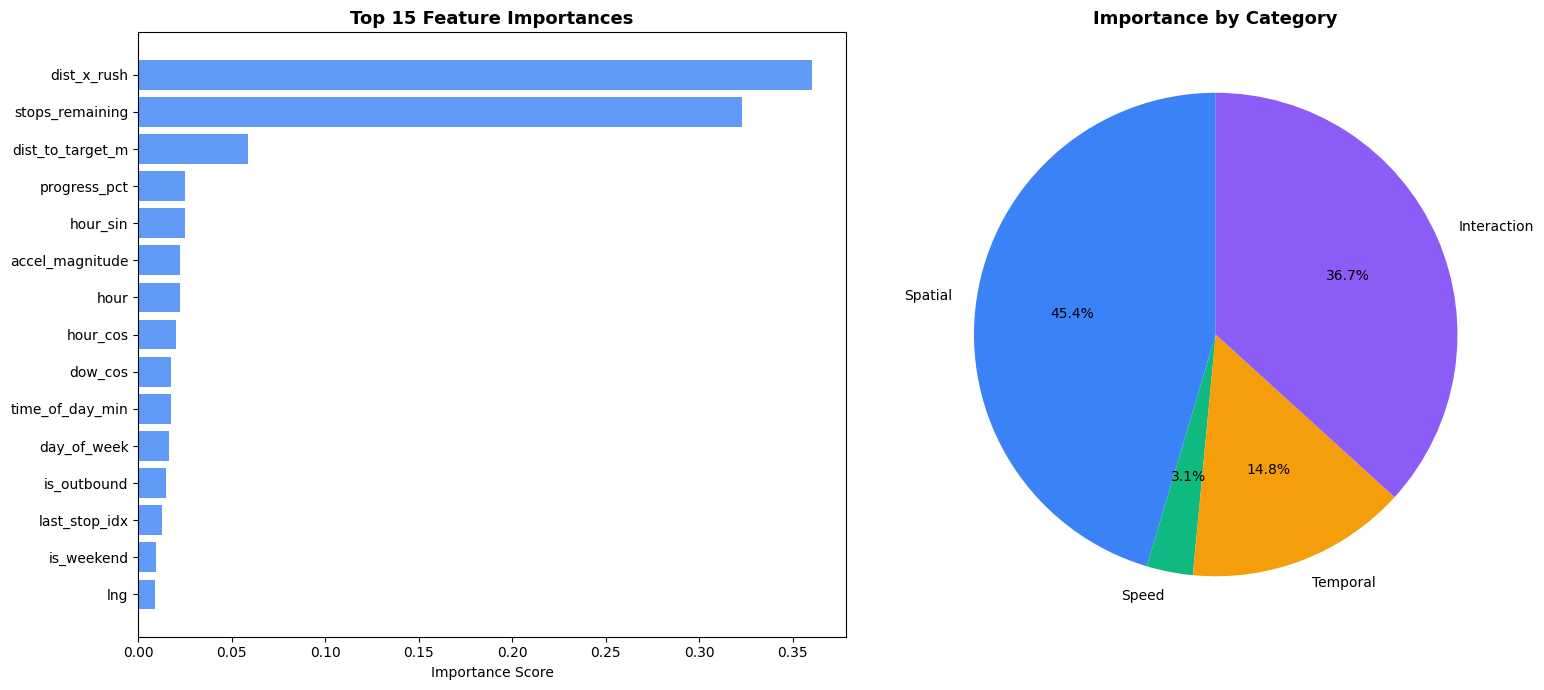

In [12]:
print('Feature Importance Analysis\n')

importance_df = pd.DataFrame({
    'feature'    : FEATURES,
    'importance' : model.feature_importances_
}).sort_values('importance', ascending=False)

print('Top 15 features:')
print(importance_df.head(15).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Feature importance bar
top15 = importance_df.head(15)
axes[0].barh(top15['feature'][::-1], top15['importance'][::-1], color='#3b82f6', alpha=0.8)
axes[0].set_title('Top 15 Feature Importances', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance Score')

# Feature importance grouped by category
categories = {
    'Spatial'  : ['lat','lng','dist_to_target_m','stops_remaining','last_stop_idx','target_stop_idx','progress_pct','is_outbound'],
    'Speed'    : ['speed_mps','speed_kmh','is_slow','is_stopped','accel_magnitude','gyro_magnitude','accuracy'],
    'Temporal' : ['hour','minute','day_of_week','is_weekend','is_rush_hour','time_of_day_min','hour_sin','hour_cos','dow_sin','dow_cos','elapsed_sec'],
    'Interaction': ['traffic_score','rush_x_stops','dist_x_rush'],
}
cat_imp = {}
for cat, feats in categories.items():
    cat_imp[cat] = importance_df[importance_df['feature'].isin(feats)]['importance'].sum()

colors = ['#3b82f6','#10b981','#f59e0b','#8b5cf6']
axes[1].pie(cat_imp.values(), labels=cat_imp.keys(), autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Importance by Category', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## **Per-Stop ETA Analysis**
> How accurate is the model for each individual stop?

Per-Stop ETA Accuracy

                                   mae  count  mean_eta
target_stop_name                                       
Ratmalana Airport                 0.85   2379      5.81
Katuwawala                        0.79   2827      6.13
Golumadama Junction               1.30   2817      6.41
Vijaya Mawathe                    1.16   4888      7.08
Ratmalana Hindu College           1.05   4888      7.21
Jayanthi Place                    0.70   6779     10.11
Samanala Road                     1.27  11532     10.34
Sethsiri Road                     1.06  12150     10.43
8th Cross Lane                    1.11  11935     10.50
Peiris Mawatha                    1.07  12006     10.52
10th Mile Post Rd                 1.53   4933     10.55
Kahatagahawatte Road              1.03  12137     10.62
Stein Studio                      1.29  11252     11.19
Metishuddagara Mawathe (Wanguwa)  1.10  12648     11.28
Gangarama Junction                1.25  13128     12.32
Belekkade Junction       

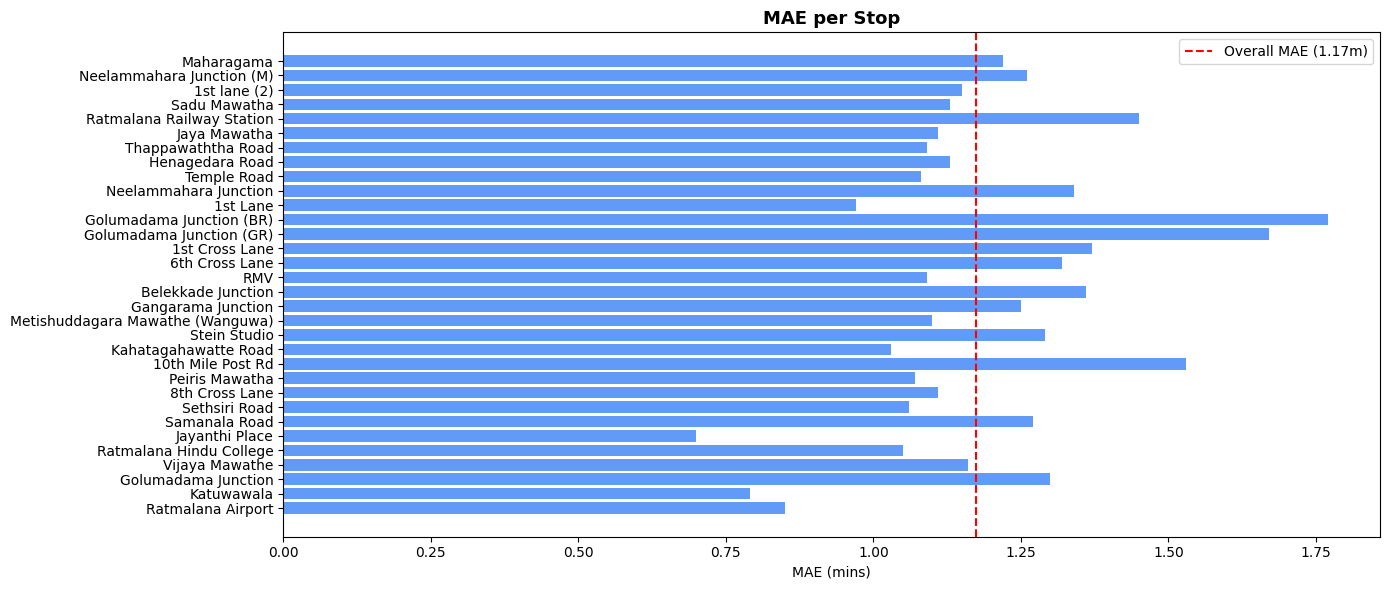

In [13]:
print('Per-Stop ETA Accuracy\n')

test_full = df_model.iloc[test_idx].copy() if len(trip_files) >= 4 else df_model.sample(frac=0.2, random_state=42)
test_full['predicted_eta'] = model.predict(X_test if len(trip_files) >= 4 else X.loc[test_full.index])
test_full['abs_error'] = np.abs(test_full['eta_minutes'] - test_full['predicted_eta'])

stop_acc = test_full.groupby('target_stop_name').agg(
    mae=('abs_error','mean'),
    count=('abs_error','count'),
    mean_eta=('eta_minutes','mean')
).round(2).sort_values('mean_eta')

print(stop_acc.to_string())

plt.figure(figsize=(14, 6))
plt.barh(stop_acc.index, stop_acc['mae'], color='#3b82f6', alpha=0.8)
plt.axvline(mae_test, color='red', lw=1.5, linestyle='--', label=f'Overall MAE ({mae_test:.2f}m)')
plt.title('MAE per Stop', fontsize=13, fontweight='bold')
plt.xlabel('MAE (mins)')
plt.legend()
plt.tight_layout()
plt.show()

## **Export Model & Metadata**

In [14]:
print('Exporting model files...\n')

# ── Enter route number ────────────────────────────────────────────────
ROUTE_ID = input('Enter route number (e.g. 256-341-1): ').strip()
if not ROUTE_ID:
    raise ValueError('Route number cannot be empty')
print(f'Route ID set to: {ROUTE_ID}\n')

MODEL_FILE    = f'TransitLK_{ROUTE_ID}_ETA.pkl'
META_FILE     = f'TransitLK_{ROUTE_ID}_ETA_metadata.json'
STOPS_FILE    = f'TransitLK_{ROUTE_ID}_ETA_stops.json'

# Save model
joblib.dump(model, MODEL_FILE)

# Stops data with average inter-stop travel times
# Compute average travel time between consecutive stops from training data
avg_times = {}
for direction in ['OUTBOUND','RETURN']:
    d = df_model[df_model['direction'] == direction]
    stops_list = STOPS_OUT_LIST if direction == 'OUTBOUND' else STOPS_RET_LIST
    avg_times[direction] = {}
    for i in range(len(stops_list) - 1):
        seg = d[(d['last_stop_idx'] == i) & (d['target_stop_idx'] == i+1)]
        if len(seg) > 0:
            avg_times[direction][f'{i}→{i+1}'] = round(seg['eta_minutes'].median(), 2)

# Stops JSON for dashboard
stops_data = {
    'route_id'       : ROUTE_ID,
    'label_outbound' : LABEL_OUT,
    'label_return'   : LABEL_RET,
    'outbound'       : STOPS_OUT_LIST,
    'return'         : STOPS_RET_LIST,
    'avg_travel_times': avg_times,  # fallback for dashboard when model not available
}
with open(STOPS_FILE, 'w') as f:
    json.dump(stops_data, f, indent=2)

# Metadata
metadata = {
    'route_id'           : ROUTE_ID,
    'model_name'         : f'TransitLK ETA — {ROUTE_ID}',
    'model_type'         : 'XGBRegressor',
    'label_outbound'     : LABEL_OUT,
    'label_return'       : LABEL_RET,
    'features'           : FEATURES,
    'n_features'         : len(FEATURES),
    'target'             : 'eta_minutes',
    'training_samples'   : int(len(X_train)),
    'test_samples'       : int(len(X_test)),
    'n_trips'            : len(trip_files),
    'mae_train'          : round(float(mae_train), 4),
    'mae_test'           : round(float(mae_test), 4),
    'rmse_test'          : round(float(rmse_test), 4),
    'r2_test'            : round(float(r2_test), 4),
    'within_2min_pct'    : round(float(within_2), 4),
    'within_5min_pct'    : round(float(within_5), 4),
    'n_stops_outbound'   : len(STOPS_OUTBOUND),
    'n_stops_return'     : len(STOPS_RETURN),
    'best_iteration'     : int(model.best_iteration),
    'training_date'      : datetime.now().strftime('%Y-%m-%d'),
    'detection_radius_m' : DETECTION_RADIUS,
    'gps_interval_sec'   : GPS_INTERVAL_SEC,
}
with open(META_FILE, 'w') as f:
    json.dump(metadata, f, indent=2)

print('Files ready:')
print(f'  {MODEL_FILE}  (XGBoost model)')
print(f'  {META_FILE}   (metadata + metrics)')
print(f'  {STOPS_FILE}  (stops + avg travel times for dashboard)')

print(f'\nModel Summary:')
print(f'  Route       : {ROUTE_ID}')
print(f'  MAE (test)  : {mae_test:.2f} mins')
print(f'  RMSE (test) : {rmse_test:.2f} mins')
print(f'  R²          : {r2_test:.4f}')
print(f'  Within ±2m  : {within_2:.1%}')
print(f'  Within ±5m  : {within_5:.1%}')
print(f'  Trips used  : {len(trip_files)}')
print(f'  Samples     : {len(X_train)} train / {len(X_test)} test')

files.download(MODEL_FILE)
files.download(META_FILE)
files.download(STOPS_FILE)

print('\nAll files downloaded!')

Exporting model files...

Enter route number (e.g. 256-341-1): 256-341-1
Route ID set to: 256-341-1

Files ready:
  TransitLK_256-341-1_ETA.pkl  (XGBoost model)
  TransitLK_256-341-1_ETA_metadata.json   (metadata + metrics)
  TransitLK_256-341-1_ETA_stops.json  (stops + avg travel times for dashboard)

Model Summary:
  Route       : 256-341-1
  MAE (test)  : 1.17 mins
  RMSE (test) : 1.85 mins
  R²          : 0.9661
  Within ±2m  : 82.6%
  Within ±5m  : 96.3%
  Trips used  : 53
  Samples     : 1111748 train / 335362 test


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All files downloaded!


## **Export ONNX Model** (for browser prediction, no server needed)

In [17]:
# ── ONNX Export ───────────────────────────────────────────────────────
# Converts the XGBoost model to ONNX format so it can run directly
# in the browser using onnxruntime-web — no Flask, no Cloud Run needed.

!pip install skl2onnx onnxmltools onnxruntime -q

import onnxmltools
from onnxmltools.convert import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType
import onnxruntime as rt
import numpy as np
import xgboost as xgb

ONNX_FILE    = f'TransitLK_{ROUTE_ID}_ETA.onnx'
FEATURES_FILE = f'TransitLK_{ROUTE_ID}_ETA_features.json'

print(f'Converting model to ONNX...')
print(f'  Features: {len(FEATURES)}')

# ── Fix: onnxmltools needs anonymous feature names (f0, f1, ...)
# We retrain an identical booster on the same data but with generic names,
# then swap the booster back — zero accuracy loss, just renames internally.
X_anon = X.copy()
X_anon.columns = [f'f{i}' for i in range(len(FEATURES))]

X_train_anon = X_anon.iloc[train_idx] if len(trip_files) >= 4 else X_anon.sample(frac=0.8, random_state=42)
X_test_anon  = X_anon.iloc[test_idx]  if len(trip_files) >= 4 else X_anon.drop(X_train_anon.index)
y_train_anon = y.loc[X_train_anon.index]

model_anon = xgb.XGBRegressor(
    n_estimators     = model.best_iteration + 1,
    max_depth        = model.get_params()['max_depth'],
    learning_rate    = model.get_params()['learning_rate'],
    subsample        = model.get_params()['subsample'],
    colsample_bytree = model.get_params()['colsample_bytree'],
    min_child_weight = model.get_params()['min_child_weight'],
    gamma            = model.get_params()['gamma'],
    reg_alpha        = model.get_params()['reg_alpha'],
    reg_lambda       = model.get_params()['reg_lambda'],
    random_state     = 42,
    n_jobs           = -1
)
model_anon.fit(X_train_anon, y_train_anon)
print('  Anonymous model trained')

# ── Convert to ONNX ───────────────────────────────────────────────────
initial_type = [('float_input', FloatTensorType([None, len(FEATURES)]))]
onnx_model = convert_xgboost(model_anon, initial_types=initial_type, target_opset=12)

with open(ONNX_FILE, 'wb') as f:
    f.write(onnx_model.SerializeToString())
print(f'  Saved: {ONNX_FILE}')

# ── Verify: compare original vs ONNX on test sample ──────────────────
print('\nVerifying ONNX output...')
sess = rt.InferenceSession(ONNX_FILE)
input_name  = sess.get_inputs()[0].name
output_name = sess.get_outputs()[0].name

sample_named = X_test.iloc[[0]].values.astype(np.float32)
sample_anon  = X_test_anon.iloc[[0]].values.astype(np.float32)

pred_orig = float(model.predict(X_test.iloc[[0]])[0])
pred_onnx = float(sess.run([output_name], {input_name: sample_anon})[0][0])

print(f'  Original XGBoost : {pred_orig:.4f} mins')
print(f'  ONNX output      : {pred_onnx:.4f} mins')
print(f'  Difference       : {abs(pred_orig - pred_onnx):.4f} mins')

# ── Save feature order JSON ───────────────────────────────────────────
# Admin app uses this to build the input tensor in the exact right order
with open(FEATURES_FILE, 'w') as f:
    json.dump({'features': FEATURES, 'n_features': len(FEATURES)}, f, indent=2)

print(f'\nReady for browser deployment:')
print(f'  {ONNX_FILE}       → drop into transitlk-admin/')
print(f'  {FEATURES_FILE}   → drop into transitlk-admin/')
print(f'  (keep your existing _stops.json too)')

files.download(ONNX_FILE)
files.download(FEATURES_FILE)
print('\nDone!')


Converting model to ONNX...
  Features: 29
  Anonymous model trained
  Saved: TransitLK_256-341-1_ETA.onnx

Verifying ONNX output...
  Original XGBoost : 2.1652 mins
  ONNX output      : 2.1652 mins
  Difference       : 0.0000 mins

Ready for browser deployment:
  TransitLK_256-341-1_ETA.onnx       → drop into transitlk-admin/
  TransitLK_256-341-1_ETA_features.json   → drop into transitlk-admin/
  (keep your existing _stops.json too)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done!


## **Next Steps — Dashboard Integration**

The exported files integrate with the TransitLK admin dashboard:

| File | Used for |
|------|----------|
| `*_eta_model.pkl` | Deploy as a Python API (Flask/FastAPI) for live predictions |
| `*_eta_stops.json` | Upload to dashboard — contains stops + avg travel times as fallback ETA |
| `*_eta_metadata.json` | Reference — features list, model metrics, route info |

**To get live ETA in the dashboard (no server needed):**  
The `avg_travel_times` in `*_eta_stops.json` can be used directly by the dashboard  
to estimate ETA for each upcoming stop based on current stop index + time of day.

**To use the full ML model:**  
Deploy a minimal Flask API on Railway/Render (free tier) that accepts current bus data  
and returns ETA for all upcoming stops.